In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors
from matplotlib.gridspec import GridSpec
import geopandas as gpd
from shapely.geometry import Polygon, Point

import string
from unidecode import unidecode
# function_collection import *

In [2]:
# parameters
region_levels = ["nuts3", "nuts4"]
year = 2017

# generate colormap
cvals  = [0, 1]
colors = ["#FFFFFF","#15636A"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)


**Figure 1 -- coagglomeration illustration**

In [5]:
def mcl_matrix(df, key_columns, heatmap, cmap, size, ax=None):
    table = df[key_columns]
    
    table = pd.pivot_table(table,
        values=key_columns[2],
        index=key_columns[1],
        columns=key_columns[0],
        aggfunc=np.sum,
        margins=True,
        margins_name='total')\
        .transpose()
    
    table = table\
        .sort_values(by=["total"], ascending=False, axis=0)\
        .sort_values(by=["total"], ascending=False, axis=1)

    table = table.drop(["total"], axis=1).drop(["total"], axis=0)

    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(table, cbar=False, cmap=cmap, ax=ax)
        ax.set_xlabel("Industry", size=size, labelpad=10)
        ax.set_ylabel("Region", size=size)
        #ax.set_xticklabels("")
        ax.set_yticklabels("")
        ax.tick_params(left = False, length=5)

In [6]:
# KDE plots to illustrate distribution
def density_plot(df, key_column, colorway, xlabel_text, fontsize, ax=None):
    if ax is None:
        ax = plt.gca()

    sns.kdeplot(data=df,
        x=key_column,
        fill=True,
        color=colorway,
        linewidth=2.5,
        log_scale=False,
        zorder=2,
        ax=ax)
    
    ax.set_xlabel(xlabel_text, size=fontsize)
    ax.set_ylabel("Density", size=fontsize)
    ax.tick_params("x", labelsize=(fontsize-5))
    ax.tick_params("y", labelsize=(fontsize-5))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

In [7]:
# datasets
rca_df = pd.read_csv(f"../data/oc16_2024_febr/ir_descriptive_final_sample_{region_levels[1]}_{year}_adv.csv", sep=";")
reg_df = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_levels[1]}_{year}.csv", sep=";")
reg_df = reg_df[reg_df["ind1"] < reg_df["ind2"]]

Text(-125, 50, 'C')

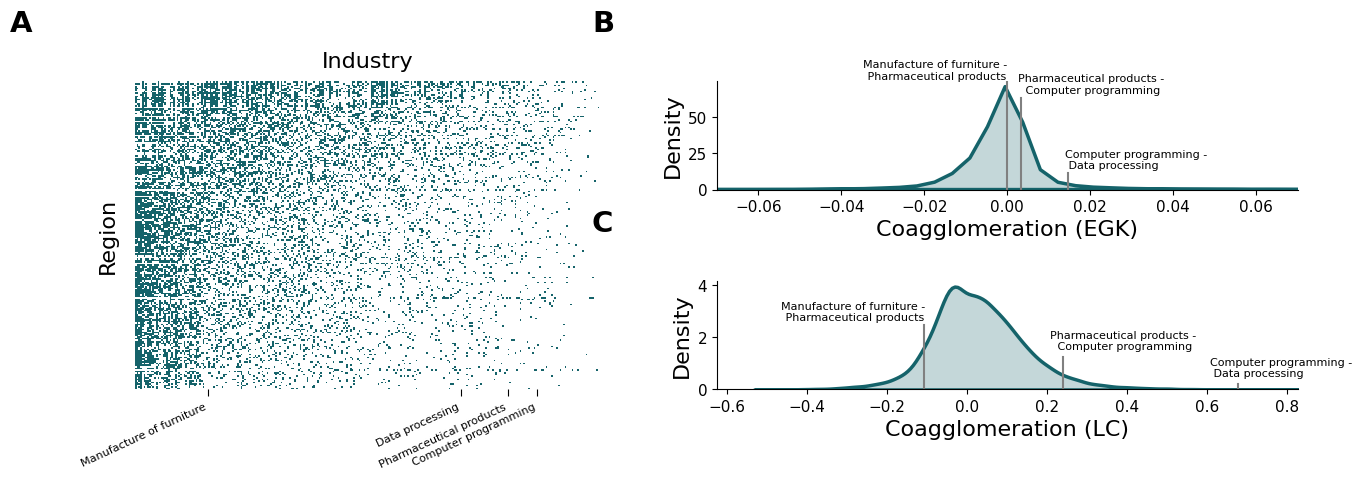

In [10]:
fig = plt.figure(figsize=(15,4))

ax = [0]*4

gs = GridSpec(2,2, figure=fig, width_ratios=[1, 1.25])
ax[0] = fig.add_subplot(gs[0:2,0])
ax[1] = fig.add_subplot(gs[0,1])
ax[2] = fig.add_subplot(gs[1,1])

fontsize = 16
fig.subplots_adjust(hspace=0.85, wspace=0.225)

# A 
mat = mcl_matrix(rca_df, key_columns=["reg", "ind", "rca01"], heatmap=False, cmap=cmap, size=fontsize)
industries = [211, 310, 620, 631]
column_positions = [mat.columns.get_loc(col) for col in industries]
column_positions[2] += 20

mcl_matrix(rca_df, key_columns=["reg", "ind", "rca01"], heatmap=True, cmap=cmap, size=fontsize, ax=ax[0])
ax[0].set_xticks(column_positions)
tick_labels = ["Pharmaceutical products", "Manufacture of furniture", "Computer programming", "Data processing"]
ax[0].set_xticklabels(tick_labels, rotation=25, ha="right", size=fontsize-8)
ax[0].xaxis.set_label_position('top')


# B-C
key_var1 = "egk_coagg"
key_var2 = "coagg_porter_rca01"


# colormap1
cvals  = [reg_df[key_var1].min(), reg_df[key_var1].max()]
colors = ["#FFFFFF","#15636A"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

density_plot(
    reg_df,
    key_column=key_var1,
    colorway=colors[1],
    xlabel_text="Coagglomeration (EGK)",
    fontsize=fontsize,
    ax=ax[1]
)
ax[1].axvline(x=0.014659, color="grey", linestyle='-', ymin=0, ymax=0.15)
ax[1].axvline(x=0.003439, color="grey", linestyle='-', ymin=0, ymax=0.85)
ax[1].axvline(x=-0.000175, color="grey", linestyle='-', ymin=0, ymax=1.1)
ax[1].set_xlim(-0.07, 0.07)
ax[1].set_zorder(100)
ax[1].text(0.375, 2.95, "Manufacture of furniture -\n Pharmaceutical products", ha='center', va='center', transform=plt.gca().transAxes, size=(fontsize-8))
ax[1].text(0.645, 2.825, "Pharmaceutical products -\n Computer programming", ha='center', va='center', transform=plt.gca().transAxes, size=(fontsize-8))
ax[1].text(0.6, 2.125, "Computer programming -\n Data processing", ha='left', va='center', transform=plt.gca().transAxes, size=(fontsize-8))



# colormap2
cvals  = [reg_df[key_var2].min(), reg_df[key_var2].max()]
colors = ["#FFFFFF","#15636A"]
norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

density_plot(
    reg_df,
    key_column=key_var2,
    colorway=colors[1],
    xlabel_text="Coagglomeration (LC)",
    fontsize=fontsize,
    ax=ax[2]
)
ax[2].axvline(x=0.676393, color="grey", linestyle='-', ymin=0, ymax=0.05, zorder=2)
ax[2].axvline(x=0.239513, color="grey", linestyle='-', ymin=0, ymax=0.3, zorder=2)
ax[2].axvline(x=-0.107074, color="grey", linestyle='-', ymin=0, ymax=0.6, zorder=2)
ax[2].set_xlim(-0.625, 0.825)
ax[2].text(0.235, 0.7175, "Manufacture of furniture -\n Pharmaceutical products", ha='center', va='center', transform=plt.gca().transAxes, size=(fontsize-8))
ax[2].text(0.7, 0.45, "Pharmaceutical products -\n Computer programming", ha='center', va='center', transform=plt.gca().transAxes, size=(fontsize-8))
ax[2].text(0.85, 0.2, "Computer programming -\n Data processing", ha='left', va='center', transform=plt.gca().transAxes, size=(fontsize-8))


# subplot title
#for a, label in zip(ax, ['A','B','C','D']):
#    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[0].annotate("A", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[1].annotate("B", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[2].annotate("C", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize+5)


# plt.savefig(f"../figures/mf01_coagglomeration.png", dpi=300, bbox_inches='tight', facecolor="white")

**Figure 2 - interplots**

In [3]:
# data from /code/95b_regressions_main.R
mf_df = pd.read_csv("../outputs/marginal_effects_for_interplots.csv", sep=";")

In [4]:
def custom_interplot(df, setting_vector, fontsize, ax=None):
    df = df[(df["dep_var"]==setting_vector[0]) & (df["y_values"]==setting_vector[1]) & (df["x_var"]==setting_vector[2])]
    
    if ax is None: 
        ax = plt.gca()
    ax.plot(df["x_values"], df["AME"], color="black", zorder=4)
    ax.plot(df["x_values"], df["upper"], color="#15636A", zorder=4)
    ax.plot(df["x_values"], df["lower"], color="#15636A", zorder=4)
    ax.fill_between(df["x_values"], df["lower"], df["upper"], color="#15636A", alpha=0.3, zorder=3)
    ax.axhline(y=0, color='black', linestyle='--', zorder=2)
    ax.tick_params("x", labelsize=(fontsize-5))
    ax.tick_params("y", labelsize=(fontsize-5))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

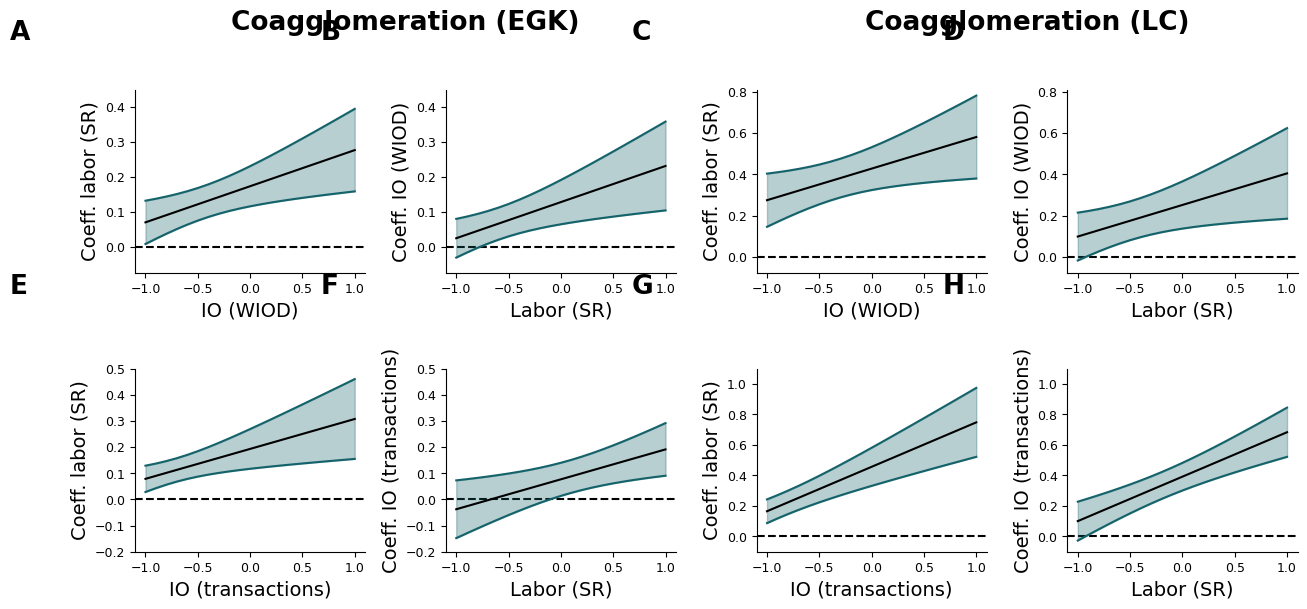

In [10]:
fig, ax = plt.subplots(2,4, figsize=(15, 6))
plt.subplots_adjust(wspace=0.35, hspace=0.525)
fontsize=14


title_text = "Coagglomeration (EGK)"
fig.text((ax[0, 0].get_position().x0 + ax[0, 1].get_position().x1) / 2, 
         ax[0, 0].get_position().y1 + 0.1,
         title_text, ha="center", weight="bold", fontsize=fontsize+5)
title_text = "Coagglomeration (LC)"
fig.text((ax[0, 2].get_position().x0 + ax[0, 3].get_position().x1) / 2, 
         ax[0, 2].get_position().y1 + 0.1,
         title_text, ha="center", weight="bold", fontsize=fontsize+5)


custom_interplot(mf_df, setting_vector=["egk_coagg_stand_nuts4", "sr_norm", "io_wiot_hun"], fontsize=fontsize, ax=ax[0,0])
ax[0,0].set_ylim(-0.075, 0.45)
ax[0,0].set_ylabel("Coeff. labor (SR)", size=fontsize)
ax[0,0].set_xlabel("IO (WIOD)", size=fontsize)

custom_interplot(mf_df, setting_vector=["egk_coagg_stand_nuts4", "io_wiot_hun", "sr_norm"], fontsize=fontsize, ax=ax[0,1])
ax[0,1].set_ylim(-0.075, 0.45)
ax[0,1].set_ylabel("Coeff. IO (WIOD)", size=fontsize)
ax[0,1].set_xlabel("Labor (SR)", size=fontsize)


custom_interplot(mf_df, setting_vector=["egk_coagg_stand_nuts4", "sr_norm", "io_norm3"], fontsize=fontsize, ax=ax[1,0])
ax[1,0].set_ylim(-0.2, 0.5)
ax[1,0].set_ylabel("Coeff. labor (SR)", size=fontsize)
ax[1,0].set_xlabel("IO (transactions)", size=fontsize)

custom_interplot(mf_df, setting_vector=["egk_coagg_stand_nuts4", "io_norm3", "sr_norm"], fontsize=fontsize, ax=ax[1,1])
ax[1,1].set_ylim(-0.2, 0.5)
ax[1,1].set_ylabel("Coeff. IO (transactions)", size=fontsize)
ax[1,1].set_xlabel("Labor (SR)", size=fontsize)


custom_interplot(mf_df, setting_vector=["coagg_porter_rca01_stand_nuts4", "sr_norm", "io_wiot_hun"], fontsize=fontsize, ax=ax[0,2])
ax[0,2].set_ylim(-0.075, 0.81)
ax[0,2].set_ylabel("Coeff. labor (SR)", size=fontsize)
ax[0,2].set_xlabel("IO (WIOD)", size=fontsize)

custom_interplot(mf_df, setting_vector=["coagg_porter_rca01_stand_nuts4", "io_wiot_hun", "sr_norm"], fontsize=fontsize, ax=ax[0,3])
ax[0,3].set_ylim(-0.075, 0.81)
ax[0,3].set_ylabel("Coeff. IO (WIOD)", size=fontsize)
ax[0,3].set_xlabel("Labor (SR)", size=fontsize)


custom_interplot(mf_df, setting_vector=["coagg_porter_rca01_stand_nuts4", "sr_norm", "io_norm3"], fontsize=fontsize, ax=ax[1,2])
ax[1,2].set_ylim(-0.1, 1.1)
ax[1,2].set_ylabel("Coeff. labor (SR)", size=fontsize)
ax[1,2].set_xlabel("IO (transactions)", size=fontsize)

custom_interplot(mf_df, setting_vector=["coagg_porter_rca01_stand_nuts4", "io_norm3", "sr_norm"], fontsize=fontsize, ax=ax[1,3])
ax[1,3].set_ylim(-0.1, 1.1)
ax[1,3].set_ylabel("Coeff. IO (transactions)", size=fontsize)
ax[1,3].set_xlabel("Labor (SR)", size=fontsize)

ax[0,0].annotate("A", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[0,1].annotate("B", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[0,2].annotate("C", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[0,3].annotate("D", xy=(0,1), xycoords='axes fraction', xytext=(-125,50), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[1,0].annotate("E", xy=(0,1), xycoords='axes fraction', xytext=(-125,75), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[1,1].annotate("F", xy=(0,1), xycoords='axes fraction', xytext=(-125,75), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[1,2].annotate("G", xy=(0,1), xycoords='axes fraction', xytext=(-125,75), textcoords='offset pixels', weight='bold', size=fontsize+5)
ax[1,3].annotate("H", xy=(0,1), xycoords='axes fraction', xytext=(-125,75), textcoords='offset pixels', weight='bold', size=fontsize+5)

plt.savefig(f"../figures/mf02_interplots.png", dpi=300, bbox_inches='tight', facecolor="white")

**Figure 2 - distance of ties -- v2**

In [29]:
# OC data in
ddf = pd.read_csv("../data/oc15_2023_dec/oc_distance_io_labor_ties.csv", sep=";")
ddf = ddf.fillna(0)

In [30]:
# re-bin distance below 50 km
factors = [10, 25, 50]
for factor in factors:
    ddf[f'dist_int{factor}'] = np.floor(ddf['dist_int'] / factor) * factor

# re-bin distance above 50 km
conditions = [
    (ddf["dist_int"] < 50),
    (ddf["dist_int"] >= 50) & (ddf["dist_int"] < 100),
    (ddf["dist_int"] >= 100) & (ddf["dist_int"] < 200),
    (ddf["dist_int"] >= 200) & (ddf["dist_int"] < 500),
    (ddf["dist_int"] >= 500),
]

choices = [
    ddf["dist_int"],
    ddf["dist_int10"],
    ddf["dist_int25"],
    ddf["dist_int50"],
    np.nan,
]

ddf["dist_combined"] = np.select(conditions, choices, default=np.nan)

In [31]:
# group by dist_combined and calculate aggregated values
agg_cols = ["poss_ties", "obs_io", "obs_labor", "obs_overlap", "nr_io_sr_ties", "io_diff_ind"]
ddf2 = ddf.groupby(["dist_combined"])[agg_cols].sum().reset_index()

# calculate probabilities
prob_cols = ["prob_io", "prob_labor", "prob_overlap"]
ddf2[prob_cols] = ddf2[["obs_io", "obs_labor", "obs_overlap"]].div(ddf2["poss_ties"], axis=0)

# calculate logs
ddf2["log_dist_combined"] = np.log10(ddf2["dist_combined"] + 1)
ddf2[[f"log_{col}" for col in prob_cols]] = ddf2[prob_cols].apply(lambda x: np.log10(x))

# standard errors for proportions sqrt(p*(1-p)/n) -- p : proportion, n : sample size
ddf2["se_io"] = np.sqrt(ddf2["prob_io"]*(1-ddf2["prob_io"]) / np.sqrt(ddf2["poss_ties"]))
ddf2["se_labor"] = np.sqrt(ddf2["prob_labor"]*(1-ddf2["prob_labor"]) / np.sqrt(ddf2["poss_ties"]))
ddf2["se_overlap"] = np.sqrt(ddf2["prob_overlap"]*(1-ddf2["prob_overlap"]) / np.sqrt(ddf2["poss_ties"]))

# calculate confidence intervals
ddf2["log_prob_labor_conf_up"] = ddf2["log_prob_labor"] - 1.96*(ddf2["se_labor"])
ddf2["log_prob_labor_conf_down"] = ddf2["log_prob_labor"] + 1.96*(ddf2["se_labor"])
ddf2["log_prob_io_conf_up"] = ddf2["log_prob_io"] - 1.96*(ddf2["se_io"])
ddf2["log_prob_io_conf_down"] = ddf2["log_prob_io"] + 1.96*(ddf2["se_io"])
ddf2["log_prob_overlap_conf_up"] = ddf2["log_prob_overlap"] - 1.96*(ddf2["se_overlap"])
ddf2["log_prob_overlap_conf_down"] = ddf2["log_prob_overlap"] + 1.96*(ddf2["se_overlap"])

/opt/homebrew/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [32]:
def tie_distance(df, distance_column, var_color_dict, fontsize, yaxis_text, legend_dict, ax=None):
    """function for different x: distance y: ties plots"""
    
    # data preparation
    all_columns = distance_column + list(var_color_dict.keys())
    df = df[all_columns]

    # figure preparation
    if ax is None:
        ax = plt.gca()
    for key, value in var_color_dict.items():
        ax.plot(df[distance_column], df[key], "o-", color=value, markersize=5, linewidth=3, label=legend_dict[key])
        ax.set_xlabel("Distance in km (log)", size=fontsize)
        ax.set_ylabel(yaxis_text, size=fontsize)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

In [33]:
# calculations for SR / no-SR supplier connections
ddf2["nr_io_no_sr_ties"] = ddf2["io_diff_ind"] - ddf2["nr_io_sr_ties"]
ddf2["nr_io_no_sr_ties_total"] = ddf2["nr_io_no_sr_ties"].sum()
ddf2["nr_io_sr_ties_total"] = ddf2["nr_io_sr_ties"].sum()

# shares
ddf2["share_io_no_sr_ties"] = ddf2["nr_io_no_sr_ties"] / ddf2["nr_io_no_sr_ties_total"]
ddf2["share_io_sr_ties"] = ddf2["nr_io_sr_ties"] / ddf2["nr_io_sr_ties_total"]

# standard errors for proportions sqrt(p*(1-p)/n) -- p : proportion, n : sample size
ddf2["se_io_no_sr"] = np.sqrt(ddf2["share_io_no_sr_ties"]*(1-ddf2["share_io_no_sr_ties"])) / np.sqrt(ddf2["nr_io_sr_ties_total"])
ddf2["share_io_no_sr_ties_ci"] = 1.96*(ddf2["se_io_no_sr"])
#ddf2["share_io_no_sr_ties_ci"] = ddf2["share_io_no_sr_ties"] - 1.96*(ddf2["se_io_no_sr"])
#ddf2["share_io_no_sr_ties_L"] = ddf2["share_io_no_sr_ties"] + 1.96*(ddf2["se_io_no_sr"])

ddf2["se_io_sr"] = np.sqrt(ddf2["share_io_sr_ties"]*(1-ddf2["share_io_sr_ties"])) / np.sqrt(ddf2["nr_io_sr_ties_total"])
ddf2["share_io_sr_ties_ci"] = 1.96*(ddf2["se_io_sr"])
#ddf2["share_io_no_sr_ties_L"] = ddf2["share_io_no_sr_ties"] + 1.96*(ddf2["se_for_plot"])


/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_27249/2598184273.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[0].set_xticklabels(["", "$10^0$", "", "", "", "$10^1$", "", "", "", "$10^2$", ""], size=fontsize-2)
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_27249/2598184273.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[0].set_yticklabels(["", "", "$10^{-7}$", "", "$10^{-6}$", "", "$10^{-5}$", ""], size=fontsize-2)
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_27249/2598184273.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  limited_df["dist_combined"] = limited_df["dist_combined"].astype(int)


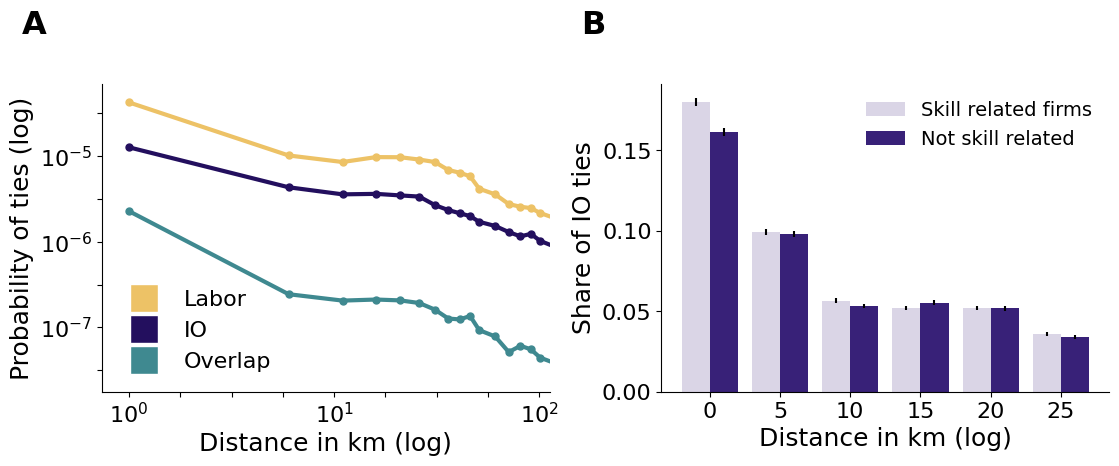

In [8]:
# distance decay figure
fig, ax = plt.subplots(1,2, figsize=(13,4))
plt.subplots_adjust(wspace=0.25)
fontsize=18


# A -- probability of ties
color_dict = {"log_prob_labor":"#EDC266", "log_prob_io":"#230F5E", "log_prob_overlap":"#3F8990"}
legend_text = {"log_prob_labor":"Labor", "log_prob_io":"IO", "log_prob_overlap":"Labor and IO"}
tie_distance(
    ddf2,
    distance_column=["log_dist_combined"],
    var_color_dict=color_dict,
    fontsize=fontsize,
    yaxis_text="Probability of ties (log)",
    legend_dict=legend_text,
    ax=ax[0]
)
ax[0].set_xlim(-0.13270882709389803, 2.05)
ax[0].set_xticklabels(["", "$10^0$", "", "", "", "$10^1$", "", "", "", "$10^2$", ""], size=fontsize-2)
#print(ax[0].get_xlim())
ax[0].set_ylim(-7.75, -4.15)
ax[0].set_yticklabels(["", "", "$10^{-7}$", "", "$10^{-6}$", "", "$10^{-5}$", ""], size=fontsize-2)
#ax[0].legend(loc="lower left", prop={'size': fontsize-4}, frameon=False)

custom_legend = [
    plt.Line2D([0], [0], marker="s", color='w', markerfacecolor="#EDC266", markersize=20),
    plt.Line2D([0], [0], marker="s", color='w', markerfacecolor="#230F5E", markersize=20),
    plt.Line2D([0], [0], marker="s", color='w', markerfacecolor="#3F8990", markersize=20)
]
ax[0].legend(custom_legend, ["Labor", "IO", "Overlap"], loc="lower left", prop={'size': fontsize-2}, frameon=False)


# B -- barplot version
limited_df = ddf2[ddf2["dist_combined"] <= 25]
limited_df["dist_combined"] = limited_df["dist_combined"].astype(int)

bar_width = 0.40
index = np.arange(len(limited_df["dist_combined"]))

ax[1].bar(
        index,
        limited_df["share_io_sr_ties"],
        bar_width,
        label="Skill related firms",
        yerr=[limited_df["share_io_sr_ties_ci"], limited_df["share_io_sr_ties_ci"]],
        capsize=0,
        #color="#EDC266"
        #color="#e6e3ed"
        color="#dad5e6"
)

ax[1].bar(
        index + bar_width,
        limited_df["share_io_no_sr_ties"],
        bar_width,
        label="Not skill related",
        yerr=[limited_df["share_io_no_sr_ties_ci"], limited_df["share_io_no_sr_ties_ci"]],
        capsize=0,
        color="#382178"
)
ax[1].set_xticks(index + bar_width / 2, limited_df["dist_combined"], size=fontsize-2)
ax[1].set_xlabel("Distance in km (log)", size=fontsize)
ax[1].set_ylabel("Share of IO ties", size=fontsize)
ax[1].tick_params("y", labelsize=(fontsize-2))
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].legend(loc="upper right", prop={'size': fontsize-4}, frameon=False)


# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-80,50), textcoords='offset pixels', weight='bold', size=fontsize+5)

# plt.savefig(f"../figures/mf03_gravity_share_sr.png", dpi=300, bbox_inches='tight', facecolor="white")

In [16]:
def ei_data_manipulation(path):
    ei_df = pd.read_csv(path, sep=";")
    if len(ei_df["ei_bin"])==21:
        ei_df["group"] = [-1, -1, -0.8, 0.8, -0.6, -0.6, -0.4, -0.4, -0.2, -0.2, 0, 0.2, 0.2, 0.4, 0.4, 0.6, 0.6, 0.8, 0.8, 1, 1]
    else:
        ei_df["group"] = [-1, -0.8, 0.8, -0.6, -0.6, -0.4, -0.4, -0.2, -0.2, 0, 0.2, 0.2, 0.4, 0.4, 0.6, 0.6, 0.8, 0.8, 1, 1]
    
    ei_df["labor_obs2"] = ei_df.groupby("group")["labor_obs"].transform("sum")
    ei_df["io_obs2"] = ei_df.groupby("group")["io_obs"].transform("sum")
    
    ei_df["total_labor"] = ei_df["labor_obs"].sum()
    ei_df["total_io"] = ei_df["io_obs"].sum()
    ei_df["labor_norm"] = ei_df["labor_obs2"] / ei_df["total_labor"]
    ei_df["io_norm"] = ei_df["io_obs2"] / ei_df["total_io"]

    ei_df["se_io_norm"] = np.sqrt(ei_df["io_norm"]*(1-ei_df["io_norm"])) / np.sqrt(ei_df["total_io"])
    ei_df["io_norm_ci"] = 1.96*(ei_df["se_io_norm"])
    ei_df["se_labor_norm"] = np.sqrt(ei_df["labor_norm"]*(1-ei_df["labor_norm"])) / np.sqrt(ei_df["total_labor"])
    ei_df["labor_norm_ci"] = 1.96*(ei_df["se_labor_norm"])

    ei_df = ei_df[["group", "labor_norm", "io_norm", "io_norm_ci", "labor_norm_ci"]].drop_duplicates()
    return ei_df

/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_27500/2471178231.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0,0].set_xticklabels(["", "$10^0$", "", "", "", "$10^1$", "", "", "", "$10^2$", ""], size=fontsize-2)
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_27500/2471178231.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0,0].set_yticklabels(["", "", "$10^{-7}$", "", "$10^{-6}$", "", "$10^{-5}$", ""], size=fontsize-2)
/var/folders/9d/8j37_fks51x11mk0_zwqsd940000gn/T/ipykernel_27500/2471178231.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-c

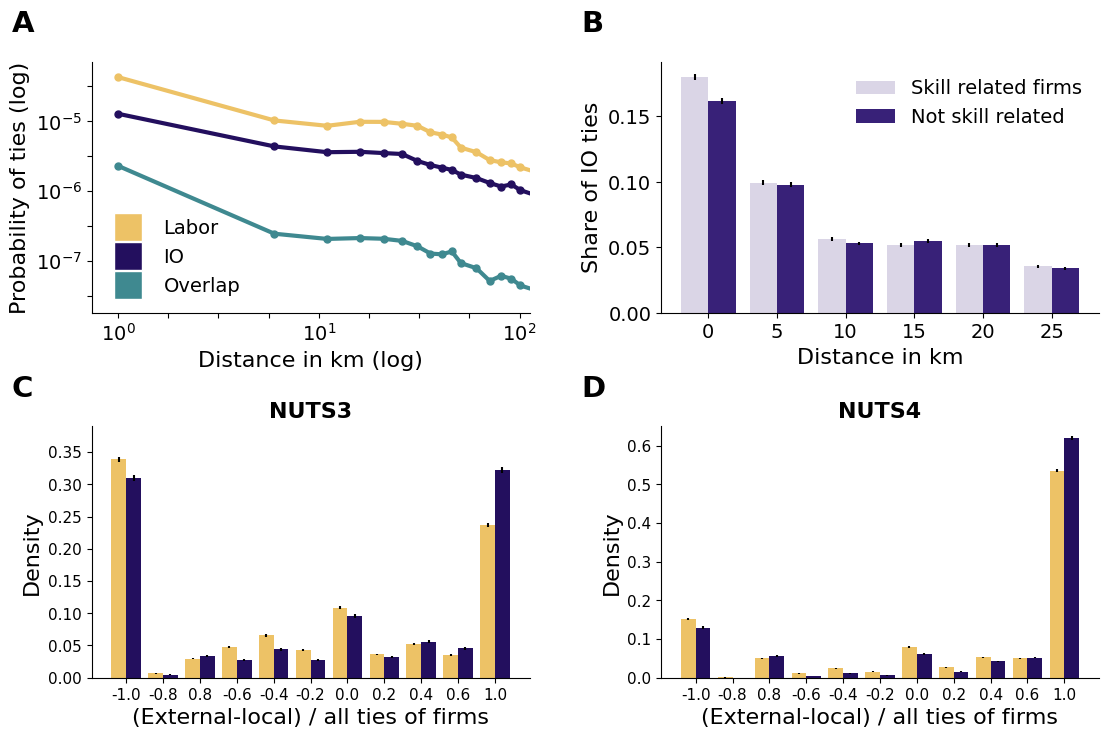

In [24]:
# distance decay figure
fig, ax = plt.subplots(2,2, figsize=(13,8))
plt.subplots_adjust(wspace=0.3, hspace=0.45)
fontsize=16

# A -- probability of ties
color_dict = {"log_prob_labor":"#EDC266", "log_prob_io":"#230F5E", "log_prob_overlap":"#3F8990"}
legend_text = {"log_prob_labor":"Labor", "log_prob_io":"IO", "log_prob_overlap":"Labor and IO"}
tie_distance(
    ddf2,
    distance_column=["log_dist_combined"],
    var_color_dict=color_dict,
    fontsize=fontsize,
    yaxis_text="Probability of ties (log)",
    legend_dict=legend_text,
    ax=ax[0,0]
)
ax[0,0].set_xlim(-0.13270882709389803, 2.05)
ax[0,0].set_xticklabels(["", "$10^0$", "", "", "", "$10^1$", "", "", "", "$10^2$", ""], size=fontsize-2)
#print(ax[0].get_xlim())
ax[0,0].set_ylim(-7.75, -4.15)
ax[0,0].set_yticklabels(["", "", "$10^{-7}$", "", "$10^{-6}$", "", "$10^{-5}$", ""], size=fontsize-2)
custom_legend = [
    plt.Line2D([0], [0], marker="s", color='w', markerfacecolor="#EDC266", markersize=20),
    plt.Line2D([0], [0], marker="s", color='w', markerfacecolor="#230F5E", markersize=20),
    plt.Line2D([0], [0], marker="s", color='w', markerfacecolor="#3F8990", markersize=20)
]
ax[0,0].legend(custom_legend, ["Labor", "IO", "Overlap"], loc="lower left", prop={'size': fontsize-2}, frameon=False)


# B -- barplot version
limited_df = ddf2[ddf2["dist_combined"] <= 25]
limited_df["dist_combined"] = limited_df["dist_combined"].astype(int)

bar_width = 0.40
index = np.arange(len(limited_df["dist_combined"]))

ax[0,1].bar(
        index,
        limited_df["share_io_sr_ties"],
        bar_width,
        label="Skill related firms",
        yerr=[limited_df["share_io_sr_ties_ci"], limited_df["share_io_sr_ties_ci"]],
        capsize=0,
        #color="#EDC266"
        #color="#e6e3ed"
        color="#dad5e6"
)

ax[0,1].bar(
        index + bar_width,
        limited_df["share_io_no_sr_ties"],
        bar_width,
        label="Not skill related",
        yerr=[limited_df["share_io_no_sr_ties_ci"], limited_df["share_io_no_sr_ties_ci"]],
        capsize=0,
        color="#382178"
)
ax[0,1].set_xticks(index + bar_width / 2, limited_df["dist_combined"], size=fontsize-2)
ax[0,1].set_xlabel("Distance in km", size=fontsize)
ax[0,1].set_ylabel("Share of IO ties", size=fontsize)
ax[0,1].tick_params("y", labelsize=(fontsize-2))
ax[0,1].spines['top'].set_visible(False)
ax[0,1].spines['right'].set_visible(False)
ax[0,1].legend(loc="upper right", prop={'size': fontsize-2}, frameon=False)





# C -- NUTS3
ei_df = ei_data_manipulation(f"../data/oc15_2023_dec/oc_ei_{region_levels[0].upper()}.csv")
bar_width = 0.4
index = np.arange(len(ei_df["group"]))
ax[1,0].bar(
        index,
        ei_df["labor_norm"],
        bar_width,
        yerr=[ei_df["labor_norm_ci"], ei_df["labor_norm_ci"]],
        capsize=0,
        color="#EDC266"
)
ax[1,0].bar(
        index + bar_width,
        ei_df["io_norm"],
        bar_width,
        yerr=[ei_df["io_norm_ci"], ei_df["io_norm_ci"]],
        capsize=0,
        color="#230F5E"
)
ax[1,0].set_xticks(index + bar_width / 2, ei_df["group"], size=fontsize-2)
ax[1,0].tick_params("x", labelsize=(fontsize-5))
ax[1,0].tick_params("y", labelsize=(fontsize-5))
ax[1,0].spines['top'].set_visible(False)
ax[1,0].spines['right'].set_visible(False)
ax[1,0].set_title("NUTS3", size=fontsize, weight="bold")
ax[1,0].set_ylim(0, 0.39)
ax[1,0].set_xlabel("(External-local) / all ties of firms", size=fontsize)
ax[1,0].set_ylabel("Density", size=fontsize)


# D -- NUTS4
ei_df = ei_data_manipulation(f"../data/oc15_2023_dec/oc_ei_{region_levels[1].upper()}.csv")
bar_width = 0.4
index = np.arange(len(ei_df["group"]))
ax[1,1].bar(
        index,
        ei_df["labor_norm"],
        bar_width,
        yerr=[ei_df["labor_norm_ci"], ei_df["labor_norm_ci"]],
        capsize=0,
        color="#EDC266"
)
ax[1,1].bar(
        index + bar_width,
        ei_df["io_norm"],
        bar_width,
        yerr=[ei_df["io_norm_ci"], ei_df["io_norm_ci"]],
        capsize=0,
        color="#230F5E"
)
ax[1,1].set_xticks(index + bar_width / 2, ei_df["group"], size=fontsize-2)
ax[1,1].tick_params("x", labelsize=(fontsize-5))
ax[1,1].tick_params("y", labelsize=(fontsize-5))
ax[1,1].spines['top'].set_visible(False)
ax[1,1].spines['right'].set_visible(False)
ax[1,1].set_title("NUTS4", size=fontsize, weight="bold")
ax[1,1].set_ylim(0, 0.39)
ax[1,1].set_xlabel("(External-local) / all ties of firms", size=fontsize)
ax[1,1].set_ylabel("Density", size=fontsize)
ax[1,1].set_ylim(0, 0.65)


# subplot title
labels = list(string.ascii_uppercase)[:ax.size]
for i, label in enumerate(labels):
    row, col = divmod(i, ax.shape[1])
    ax[row, col].annotate(label, xy=(0, 1), xycoords='axes fraction', xytext=(-80, 30), textcoords='offset pixels', weight='bold', size=fontsize + 5)


# plt.savefig(f"../figures/mf03_combined_firm-to-firm.png", dpi=300, bbox_inches='tight', facecolor="white")

**distance of ties by industry**

In [3]:
# distance of ties by industry
id_table = pd.read_csv("../data/oc17_2024_febr2/ind_dist_table_nace2d_2017.csv", sep=";")

# labels for the plot
labels = pd.read_excel("../data/nace_manuf_services_labelled.xlsx")[["ind2dig", "ind_letter"]]
labels["letter2dig"] = labels["ind_letter"] + labels["ind2dig"].astype(str).str.zfill(2)
id_table = pd.merge(
    id_table,
    labels,
    left_on="ind1",
    right_on="ind2dig",
    how="left"
)

In [4]:
labels["letter2dig"] = labels["ind_letter"] + labels["ind2dig"].astype(str).str.zfill(2)

In [5]:
# manipulation
id_table["sr_dist_diff"] = id_table["avg_dist_io_sr"] - id_table["avg_dist_io_not_sr"]
id_table = id_table[id_table["nr_firms"]>=100]
id_table.sort_values(by="ind1", ascending=False, inplace=True)

#sr_io = id_table[id_table["sr_dist_diff"] <= 0]
#sr_not_io = id_table[id_table["sr_dist_diff"] > 0]

id_table["sr_dist_diff1"] = np.where(id_table["sr_dist_diff"] <= 0, id_table["sr_dist_diff"], 0)
id_table["sr_dist_diff2"] = np.where(id_table["sr_dist_diff"] > 0, id_table["sr_dist_diff"], 0)

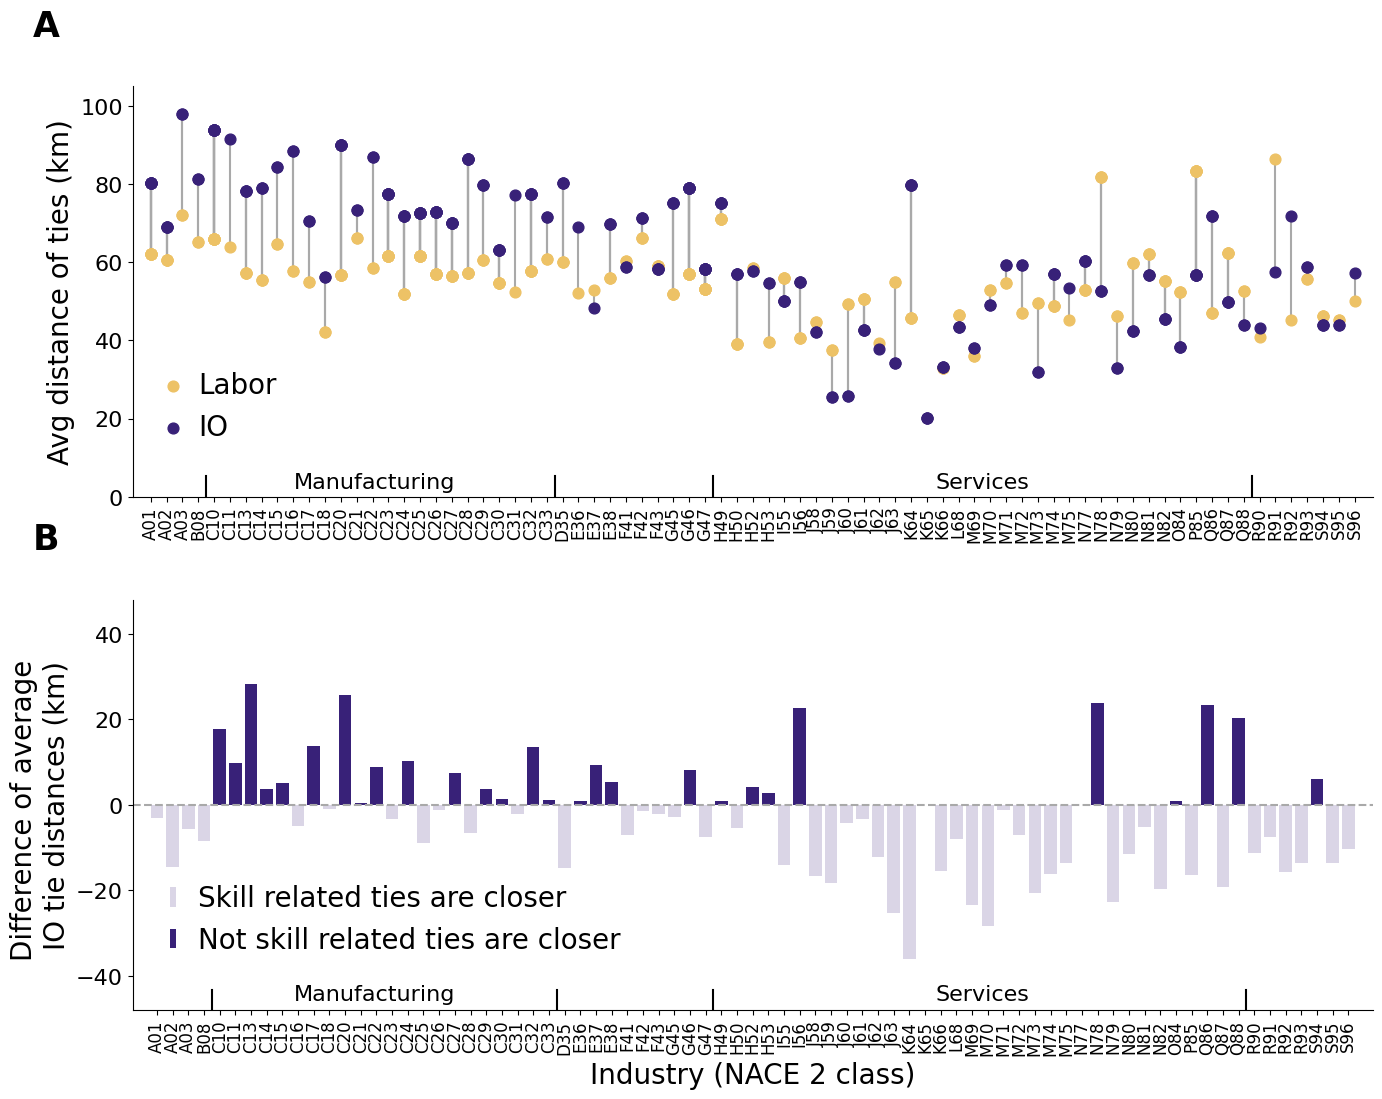

In [6]:
fig, ax = plt.subplots(2,1, figsize=(16,12))
plt.subplots_adjust(hspace=0.25)
fontsize=20
bar_width = 0.40
id_table.sort_values(by=["letter2dig"], inplace=True)

ax[0].scatter(id_table["letter2dig"], id_table["avg_dist_lab_all"], label="Labor", color="#EDC266", zorder=2, s=60)
ax[0].scatter(id_table["letter2dig"], id_table["avg_dist_io_all"], label="IO", color="#382178", zorder=2, s=60)
ax[0].vlines(id_table["letter2dig"], ymin=id_table["avg_dist_lab_all"], ymax=id_table["avg_dist_io_all"], color="darkgrey", zorder=1)
#ax[0].set_xlabel("Industry", size=fontsize)
ax[0].set_ylabel("Avg distance of ties (km)", size=fontsize)
ax[0].tick_params("x", labelsize=(fontsize-8), rotation=90)
ax[0].tick_params("y", labelsize=(fontsize-4))
ax[0].margins(0.015, tight=True)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].set_ylim(0, 105)
#ax[0].set_xlim(-2, 100)
ax[0].legend(loc="lower left", prop={'size': fontsize}, bbox_to_anchor=(0.01, 0.075), handlelength=0.2, frameon=False)
ax[0].text(0.195, 1.285, "Manufacturing", ha='center', va='center', transform=plt.gca().transAxes, size=(fontsize-4))
ax[0].text(0.685, 1.285, "Services", ha='center', va='center', transform=plt.gca().transAxes, size=(fontsize-4))
ax[0].axvline(x=3.5, color="black", linestyle='-', ymin=0, ymax=0.05)
ax[0].axvline(x=25.5, color="black", linestyle='-', ymin=0, ymax=0.05)
ax[0].axvline(x=35.5, color="black", linestyle='-', ymin=0, ymax=0.05)
ax[0].axvline(x=69.5, color="black", linestyle='-', ymin=0, ymax=0.05)


#ax[1].bar(id_table["letter2dig"], id_table["sr_dist_diff"], color="#382178")
#ax[1].bar(sr_io["letter2dig"], sr_io["sr_dist_diff"], color="#dad5e6")
#ax[1].bar(sr_not_io["letter2dig"], sr_not_io["sr_dist_diff"], color="#382178")
ax[1].bar(id_table["letter2dig"], id_table["sr_dist_diff1"], color="#dad5e6", label="Skill related ties are closer")
ax[1].bar(id_table["letter2dig"], id_table["sr_dist_diff2"], color="#382178", label="Not skill related ties are closer") 
ax[1].axhline(y=0, color="darkgrey", linestyle="--")
ax[1].set_xlabel("Industry (NACE 2 class)", size=fontsize)
# ax[1].set_ylabel("Diff. of average (SR - not SR)\n IO tie distances (km)", size=fontsize)
ax[1].set_ylabel("Difference of average \nIO tie distances (km)", size=fontsize)
ax[1].tick_params("x", labelsize=(fontsize-8), rotation=90)
ax[1].tick_params("y", labelsize=(fontsize-4))
ax[1].margins(0.015, tight=True)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].set_ylim(-48, 48)
#ax[1].set_xlim(-2, 100)
ax[1].legend(loc="lower left", prop={'size': fontsize}, bbox_to_anchor=(0.01, 0.075), handlelength=0.2, frameon=False)
ax[1].text(0.195, 0.0385, "Manufacturing", ha='center', va='center', transform=plt.gca().transAxes, size=(fontsize-4))
ax[1].text(0.685, 0.0385, "Services", ha='center', va='center', transform=plt.gca().transAxes, size=(fontsize-4))
ax[1].axvline(x=3.5, color="black", linestyle='-', ymin=0, ymax=0.05)
ax[1].axvline(x=25.5, color="black", linestyle='-', ymin=0, ymax=0.05)
ax[1].axvline(x=35.5, color="black", linestyle='-', ymin=0, ymax=0.05)
ax[1].axvline(x=69.5, color="black", linestyle='-', ymin=0, ymax=0.05)


# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-100,50), textcoords='offset pixels', weight='bold', size=fontsize+5)

# plt.savefig(f"../figures/mf04_distance_by_industry.png", dpi=300, bbox_inches='tight', facecolor="white")

**E-I connections**

In [82]:
ei_df = pd.read_csv(f"../data/oc15_2023_dec/oc_ei_{region_levels[1].upper()}.csv", sep=";")

In [83]:
ei_df

,ei_bin,io_obs,labor_obs,io_labor_obs
0,-1.0,4370,11466,3413
1,-0.8,6,47,2
2,-0.7,19,140,5
3,-0.6,35,281,17
4,-0.5,114,599,26
5,-0.4,29,193,3
6,-0.3,375,1655,120
7,-0.2,137,702,20
8,-0.1,85,511,9
9,0.0,2071,6017,492


,group,labor_norm,io_norm
0,-1.0,0.338621,0.310081
2,-0.8,0.007133,0.004326
3,0.8,0.029602,0.033367
4,-0.6,0.047699,0.027826
6,-0.4,0.065664,0.044124
8,-0.2,0.042679,0.027766
10,0.0,0.108713,0.096071
11,0.2,0.036207,0.032419
13,0.4,0.051979,0.055918
15,0.6,0.035176,0.045754


In [85]:
ei_data_manipulation(f"../data/oc15_2023_dec/oc_ei_{region_levels[1].upper()}.csv")

,group,labor_norm,io_norm
0,-1.0,0.151458,0.129497
1,-0.8,0.000621,0.000178
2,0.8,0.050711,0.056985
3,-0.6,0.011624,0.004415
5,-0.4,0.024411,0.011972
7,-0.2,0.016023,0.006579
9,0.0,0.079481,0.061370
10,0.2,0.026802,0.015528
12,0.4,0.052996,0.042316
14,0.6,0.050539,0.052095


In [8]:
ei_df.shape

(21, 4)

In [9]:
ei_df.head(2)

,ei_bin,io_obs,labor_obs,io_labor_obs
0,-1.0,10431,25584,5067
1,-0.9,33,51,1


In [55]:
ei_df["total_labor"] = ei_df["labor_obs"].sum()
ei_df["total_io"] = ei_df["io_obs"].sum()
ei_df["labor_norm"] = ei_df["labor_obs"] / ei_df["total_labor"]
ei_df["io_norm"] = ei_df["io_obs"] / ei_df["total_io"]

In [57]:
ei_df

,ei_bin,io_obs,labor_obs,io_labor_obs
0,-1.0,10431,25584,5067
1,-0.9,33,51,1
2,-0.8,146,540,7
3,-0.7,249,944,19
4,-0.6,386,1426,34
5,-0.5,553,2185,56
6,-0.4,277,1035,9
7,-0.3,1212,3936,167
8,-0.2,577,1921,34
9,-0.1,360,1310,24


In [80]:
ei_df = ei_data_manipulation(f"../data/oc15_2023_dec/oc_ei_{region_levels[1].upper()}.csv")

ValueError: Length of values (21) does not match length of index (20)

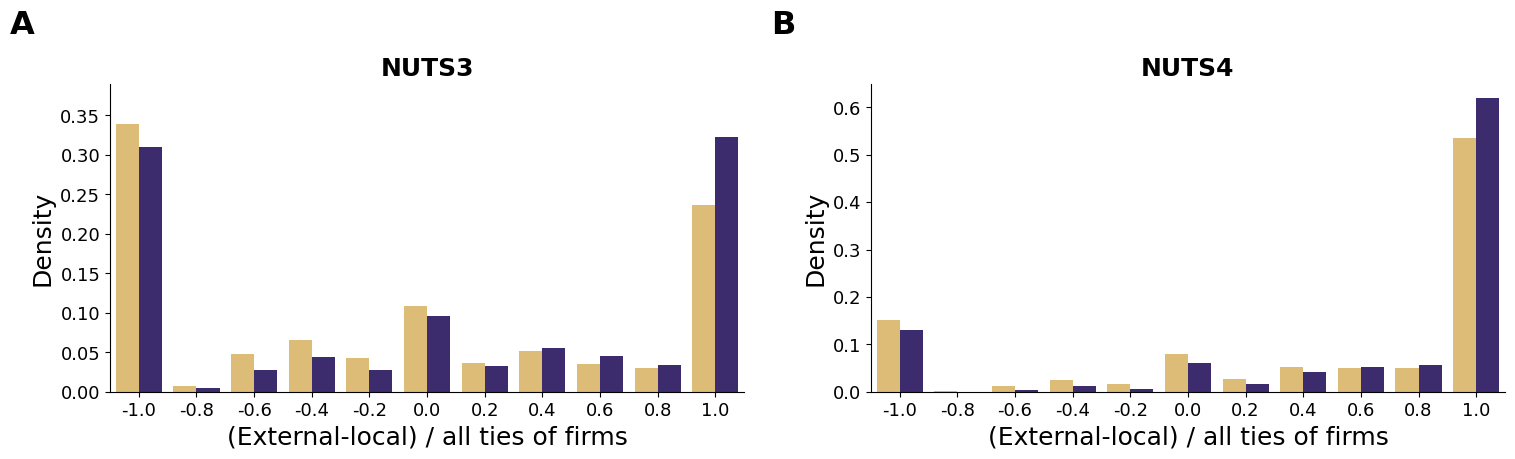

In [109]:
fig, ax = plt.subplots(1,2, figsize=(18,4))
fontsize=18
palette = {"labor_norm": "#EDC266", "io_norm": "#382178"}

# NUTS3
ei_df = ei_data_manipulation(f"../data/oc15_2023_dec/oc_ei_{region_levels[0].upper()}.csv")
df_long = pd.melt(ei_df, id_vars="group", value_vars=["labor_norm", "io_norm"], var_name="variable", value_name="value")
sns.barplot(x="group", y="value", hue="variable", data=df_long, palette=palette, ax=ax[0])
ax[0].set_xlabel("(External-local) / all ties of firms", size=fontsize)
ax[0].set_ylabel("Density", size=fontsize)
ax[0].tick_params("x", labelsize=(fontsize-5))
ax[0].tick_params("y", labelsize=(fontsize-5))
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].get_legend().set_visible(False)
ax[0].set_title("NUTS3", size=fontsize, weight="bold")
ax[0].set_ylim(0, 0.39)
#legend_labels = {"labor_norm": "Labor", "io_norm": "IO"}
#handles, _ = ax[0].get_legend_handles_labels()
#ax[0].legend(handles, [legend_labels.get(handle.get_label(), handle.get_label()) for handle in handles])


# NUTS4
ei_df = ei_data_manipulation(f"../data/oc15_2023_dec/oc_ei_{region_levels[1].upper()}.csv")
df_long = pd.melt(ei_df, id_vars="group", value_vars=["labor_norm", "io_norm"], var_name="variable", value_name="value")
sns.barplot(x="group", y="value", hue="variable", data=df_long, palette=palette, ax=ax[1])
ax[1].set_xlabel("(External-local) / all ties of firms", size=fontsize)
ax[1].set_ylabel("Density", size=fontsize)
ax[1].tick_params("x", labelsize=(fontsize-5))
ax[1].tick_params("y", labelsize=(fontsize-5))
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].get_legend().set_visible(False)
ax[1].set_title("NUTS4", size=fontsize, weight="bold")
ax[1].set_ylim(0, 0.65)

#legend_labels = {"labor_norm": "Labor", "io_norm": "IO"}
#handles, _ = ax[1].get_legend_handles_labels()
#ax[1].legend(handles, [legend_labels.get(handle.get_label(), handle.get_label()) for handle in handles])

# subplot title
for a, label in zip(ax, ['A','B','C','D']):
    a.annotate(label.upper(), xy=(0,1), xycoords='axes fraction', xytext=(-100,50), textcoords='offset pixels', weight='bold', size=fontsize+5)


In [87]:
ei_df

,group,labor_norm,io_norm
0,-1.0,0.151458,0.129497
1,-0.8,0.000621,0.000178
2,0.8,0.050711,0.056985
3,-0.6,0.011624,0.004415
5,-0.4,0.024411,0.011972
7,-0.2,0.016023,0.006579
9,0.0,0.079481,0.061370
10,0.2,0.026802,0.015528
12,0.4,0.052996,0.042316
14,0.6,0.050539,0.052095


KeyError: "The following 'value_vars' are not present in the DataFrame: ['io_norm', 'labor_norm']"

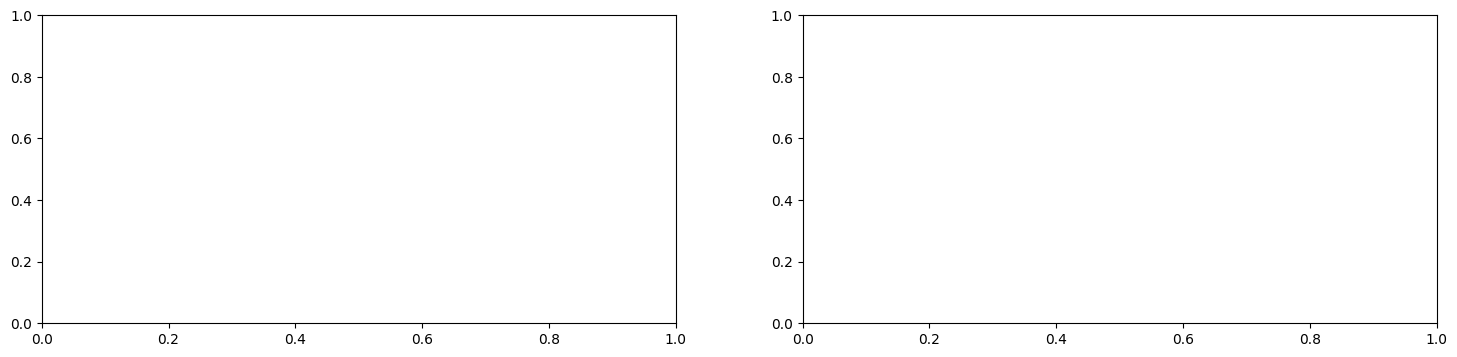

In [53]:
fig, ax = plt.subplots(1,2, figsize=(18,4))
fontsize=18
palette = {"labor_norm": "#EDC266", "io_norm": "#382178"}

# NUTS3
ei_df = pd.read_csv(f"../data/oc15_2023_dec/oc_ei_{region_levels[0].upper()}.csv", sep=";")
df_long = pd.melt(ei_df, id_vars="ei_bin", value_vars=["labor_norm", "io_norm"], var_name="variable", value_name="value")
sns.barplot(x="ei_bin", y="value", hue="variable", data=df_long, palette=palette, ax=ax[0])

#ax[0].bar(ei_df["ei_bin"], ei_df["labor_obs"], width=0.08, color="#EDC266")
#ax[0].semilogy()
ax[0].set_xlabel("(External-local) / all ties", size=fontsize)
ax[0].set_ylabel("Nr. companies", size=fontsize)
#ax[0].tick_params("x", labelsize=(fontsize-5))
#ax[0].tick_params("y", labelsize=(fontsize-5))
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

legend_labels = {"labor_norm": "Labor", "io_norm": "IO"}
handles, _ = ax[0].get_legend_handles_labels()
ax[0].legend(handles, [legend_labels.get(handle.get_label(), handle.get_label()) for handle in handles])



ei_df = pd.read_csv(f"../data/oc15_2023_dec/oc_ei_{region_levels[1].upper()}.csv", sep=";")
df_long = pd.melt(ei_df, id_vars="ei_bin", value_vars=["labor_obs", "io_obs"], var_name="variable", value_name="value")
sns.barplot(x="ei_bin", y="value", hue="variable", data=df_long, palette=palette, ax=ax[1])

#ax[1].bar(ei_df["ei_bin"], ei_df["io_obs"], width=0.08, color="#EDC266")
#ax[1].semilogy()
ax[1].set_xlabel("(External-local) / all ties", size=fontsize)
ax[1].set_ylabel("Nr. companies", size=fontsize)
ax[1].tick_params("x", labelsize=(fontsize-5))
ax[1].tick_params("y", labelsize=(fontsize-5))
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

<AxesSubplot: xlabel='group_id', ylabel='value'>

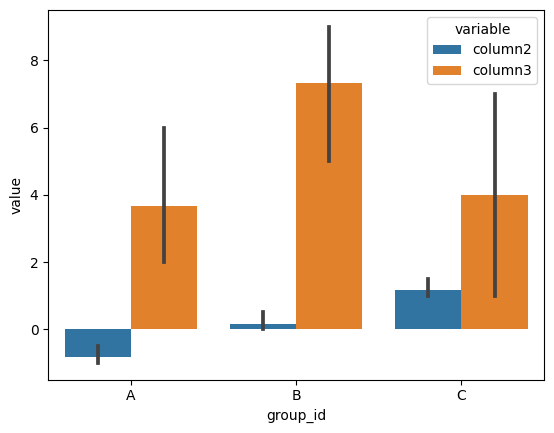

In [60]:
data = {'group_id': ['A', 'B', 'C', 'A', 'B', 'C', 'A', 'B', 'C'],
        'column2': [-1, 0, 1, -0.5, 0.5, 1.5, -1, 0, 1],
        'column3': [3, 5, 7, 2, 8, 4, 6, 9, 1]}

df = pd.DataFrame(data)

# Melt the DataFrame to create a long format suitable for Seaborn
df_long = pd.melt(df, id_vars='group_id', value_vars=['column2', 'column3'], var_name='variable', value_name='value')

# Create a grouped bar chart using Seaborn
sns.barplot(x='group_id', y='value', hue='variable', data=df_long)


In [8]:
ei_df.head(2)

,ei_bin,io_obs,labor_obs,io_labor_obs
0,-1.0,10431,25584,5067
1,-0.9,33,51,1


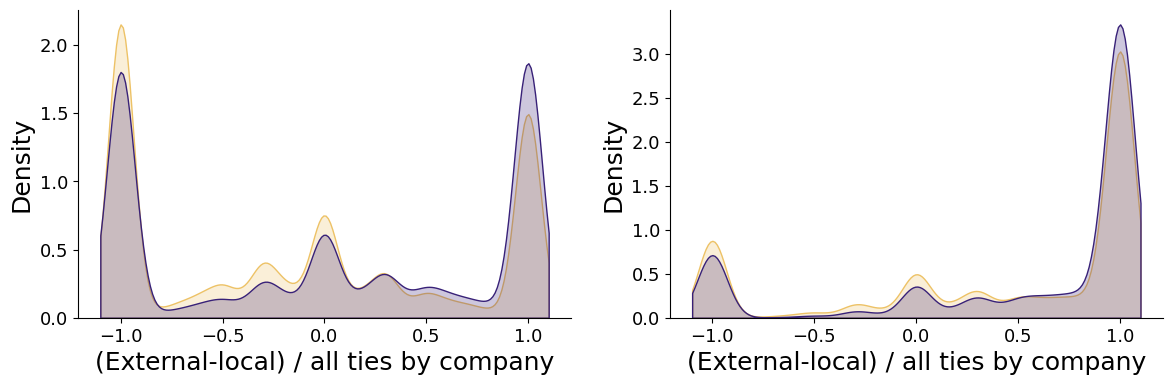

In [56]:
fig, ax = plt.subplots(1,2, figsize=(14,4))
fontsize=18
bwpar = 0.1

# NUTS3
ei_df = pd.read_csv(f"../data/oc15_2023_dec/oc_ei_{region_levels[0].upper()}.csv", sep=";")
sns.kdeplot(x=ei_df["ei_bin"], fill=True, weights=ei_df["labor_obs"], color="#EDC266", bw_adjust=bwpar, ax=ax[0])
sns.kdeplot(x=ei_df["ei_bin"], fill=True, weights=ei_df["io_obs"], color="#382178", bw_adjust=bwpar, ax=ax[0])
#ax[0].semilogy()
ax[0].set_xlabel("(External-local) / all ties by company", size=fontsize)
ax[0].set_ylabel("Density", size=fontsize)
ax[0].tick_params("x", labelsize=(fontsize-5))
ax[0].tick_params("y", labelsize=(fontsize-5))
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

# NUTS4
ei_df = pd.read_csv(f"../data/oc15_2023_dec/oc_ei_{region_levels[1].upper()}.csv", sep=";")
sns.kdeplot(x=ei_df["ei_bin"], fill=True, weights=ei_df["labor_obs"], color="#EDC266", bw_adjust=bwpar, ax=ax[1])
sns.kdeplot(x=ei_df["ei_bin"], fill=True, weights=ei_df["io_obs"], color="#382178", bw_adjust=bwpar, ax=ax[1])
#ax[0].semilogy()
ax[1].set_xlabel("(External-local) / all ties by company", size=fontsize)
ax[1].set_ylabel("Density", size=fontsize)
ax[1].tick_params("x", labelsize=(fontsize-5))
ax[1].tick_params("y", labelsize=(fontsize-5))
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)


<AxesSubplot: xlabel='ei_bin', ylabel='Density'>

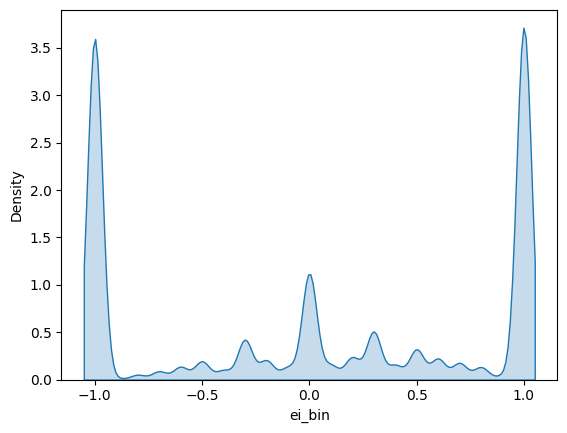

In [30]:
sns.kdeplot(x=ei_df["ei_bin"], fill=True, weights=ei_df["io_obs"], bw_adjust=0.05)

<AxesSubplot: xlabel='column1', ylabel='Density'>

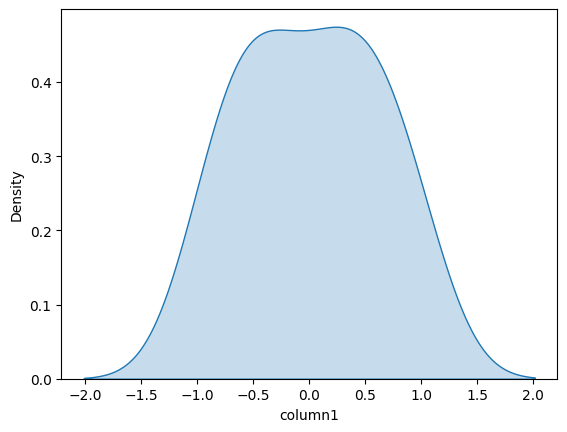

In [15]:
# Replace 'column1' and 'column2' with the actual names of your columns

# Create a sample DataFrame
data = {'column1': [-1, -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
        'column2': [3, 5, 7, 2, 8, 4, 6, 9, 1, 3, 5, 7, 2, 8, 4, 6, 9, 1, 3, 5, 7]}

df = pd.DataFrame(data)

# Sort the DataFrame by column1 for better visualization
df.sort_values(by='column1', inplace=True)

# Calculate the weighted density values
weighted_density = (df['column2'] / df['column2'].sum()).values

# Create a density plot using seaborn
sns.kdeplot(x=df['column1'], fill=True, weights=weighted_density)


<AxesSubplot: ylabel='Density'>

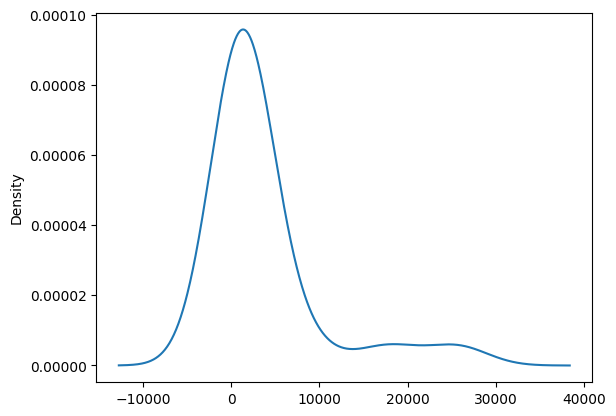

In [21]:
ei_df["labor_obs"].plot.kde()

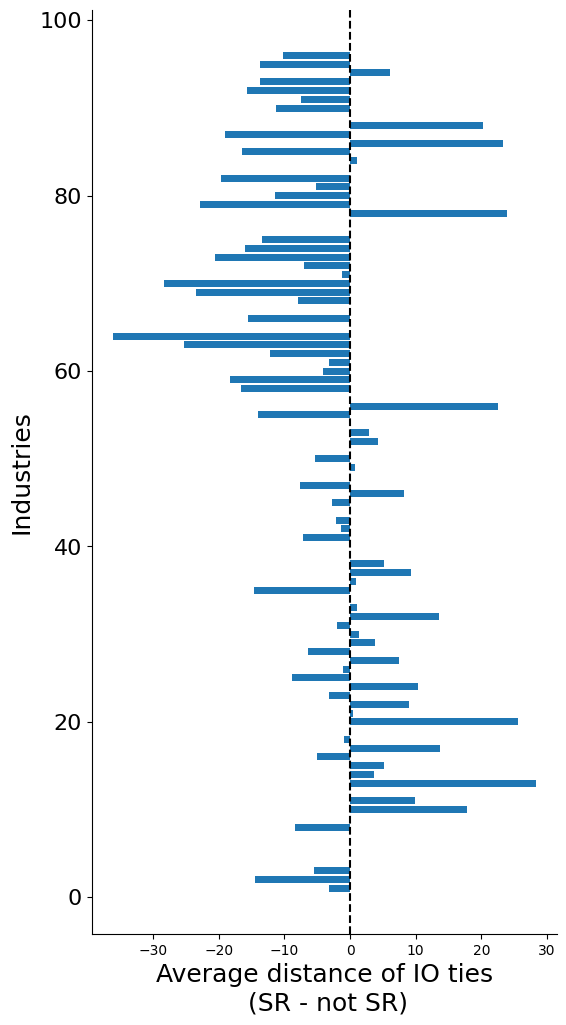

In [205]:
fig, ax = plt.subplots(1,1, figsize=(6,12))
fontsize=18
ax.barh(id_table["ind1"], id_table["sr_dist_diff"])
ax.axvline(x=0, color="black", linestyle="--")
ax.set_xlabel("Average distance of IO ties\n (SR - not SR)", size=fontsize)
ax.set_ylabel("Industries", size=fontsize)
ax.tick_params("y", labelsize=(fontsize-2))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


Text(0, 0.5, 'Distance difference of IO \nSR vs not SR ')

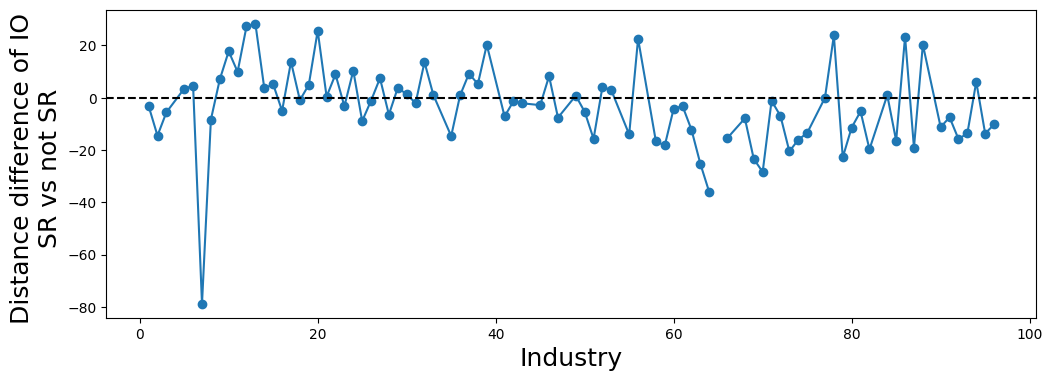

In [40]:
fig, ax = plt.subplots(1,1, figsize=(12,4))
fontsize=18
ax.plot(id_table["ind1"], id_table["sr_dist_diff"], "o-")
ax.axhline(y=0, color="black", linestyle="--")
ax.set_xlabel("Industry", size=fontsize)
ax.set_ylabel("Distance difference of IO \nSR vs not SR ", size=fontsize)

In [43]:
id_table[id_table["sr_dist_diff"] < -20]

,ind1,nr_firms,avg_dist_io_all,sd_dist_io_all,nr_ties_io_all,avg_dist_lab_all,sd_dist_lab_all,nr_ties_lab_all,avg_dist_io_diffind,sd_dist_io_diffind,...,avg_dist_lab_diffind,sd_dist_lab_diffind,nr_ties_lab_diffind,avg_dist_io_sr,sd_dist_io_sr,nr_ties_io_sr,avg_dist_io_not_sr,sd_dist_io_not_sr,nr_ties_io_not_sr,sr_dist_diff
5,7,6,72.692,57.966,13.0,55.400,65.612,25.0,72.692,57.966,...,72.692,57.966,13.0,0.000,NaN,1.0,78.750,56.081,12.0,-78.750
55,63,2206,34.269,56.218,1191.0,54.920,70.525,3439.0,35.022,56.849,...,35.022,56.849,1137.0,24.023,45.097,642.0,49.287,66.572,495.0,-25.264
56,64,1091,79.830,70.918,6842.0,45.724,60.271,156.0,80.207,70.903,...,80.207,70.903,6804.0,46.229,65.933,402.0,82.341,70.666,6402.0,-36.112
60,69,14777,38.068,59.021,3123.0,35.995,57.055,8835.0,39.953,59.475,...,39.953,59.475,2769.0,30.811,53.863,1687.0,54.207,64.797,1082.0,-23.396
61,70,8674,49.019,65.727,8501.0,52.892,69.152,14389.0,50.998,66.938,...,50.998,66.938,7643.0,41.777,62.002,5159.0,70.147,72.534,2484.0,-28.370
64,73,3855,32.005,51.882,4982.0,49.474,65.915,6876.0,36.282,55.173,...,36.282,55.173,3918.0,30.174,51.519,2751.0,50.679,60.588,1167.0,-20.505
69,79,1376,32.858,56.463,625.0,46.318,65.801,2354.0,34.969,57.955,...,34.969,57.955,557.0,29.487,53.758,423.0,52.276,66.889,134.0,-22.789


In [173]:
# ind-ind
idid_table = pd.read_csv("../data/oc17_2024_febr2/indind_dist_nace2d_2017.csv", sep=";")

In [151]:
idid_table.head(2)

,ind1,ind2,nr_firms1,nr_firms2,avg_dist_io,sd_dist_io,nr_ties_io,avg_dist_lab,sd_dist_lab,nr_ties_lab,avg_dist_io_sr,sd_dist_io_sr,nr_ties_io_sr,avg_dist_io_not_sr,sd_dist_io_not_sr,nr_ties_io_not_sr
0,1,2,17736,2328,35.917,53.779,48.0,45.171,63.712,181.0,35.917,53.779,48.0,NaN,NaN,NaN
1,1,3,17736,212,32.600,38.848,10.0,79.388,67.699,49.0,32.600,38.848,10.0,NaN,NaN,NaN


In [174]:
idid_table["avg_dist_io_sr"] = np.where(idid_table["avg_dist_io_sr"] <=25, 25, idid_table["avg_dist_io_sr"])
idid_table["avg_dist_io_sr"] = np.where((idid_table["avg_dist_io_sr"] >10) & (idid_table["avg_dist_io_sr"] <=50), 50, idid_table["avg_dist_io_sr"])
idid_table["avg_dist_io_sr"] = np.where((idid_table["avg_dist_io_sr"] >50) & (idid_table["avg_dist_io_sr"] <=100), 100, idid_table["avg_dist_io_sr"])
idid_table["avg_dist_io_sr"] = np.where((idid_table["avg_dist_io_sr"] >100) & (idid_table["avg_dist_io_sr"] <=200), 200, idid_table["avg_dist_io_sr"])
idid_table["avg_dist_io_sr"] = np.where(idid_table["avg_dist_io_sr"] >200, 300, idid_table["avg_dist_io_sr"])

idid_table["avg_dist_io_not_sr"] = np.where(idid_table["avg_dist_io_not_sr"] <=25, 25, idid_table["avg_dist_io_not_sr"])
idid_table["avg_dist_io_not_sr"] = np.where((idid_table["avg_dist_io_not_sr"] >10) & (idid_table["avg_dist_io_not_sr"] <=50), 50, idid_table["avg_dist_io_not_sr"])
idid_table["avg_dist_io_not_sr"] = np.where((idid_table["avg_dist_io_not_sr"] >50) & (idid_table["avg_dist_io_not_sr"] <=100), 100, idid_table["avg_dist_io_not_sr"])
idid_table["avg_dist_io_not_sr"] = np.where((idid_table["avg_dist_io_not_sr"] >100) & (idid_table["avg_dist_io_not_sr"] <=200), 200, idid_table["avg_dist_io_not_sr"])
idid_table["avg_dist_io_not_sr"] = np.where(idid_table["avg_dist_io_not_sr"] >200, 300, idid_table["avg_dist_io_not_sr"])

In [175]:
idid_table

,ind1,ind2,nr_firms1,nr_firms2,avg_dist_io,sd_dist_io,nr_ties_io,avg_dist_lab,sd_dist_lab,nr_ties_lab,avg_dist_io_sr,sd_dist_io_sr,nr_ties_io_sr,avg_dist_io_not_sr,sd_dist_io_not_sr,nr_ties_io_not_sr
0,1,2,17736,2328,35.917,53.779,48.0,45.171,63.712,181.0,50.0,53.779,48.0,NaN,NaN,NaN
1,1,3,17736,212,32.600,38.848,10.0,79.388,67.699,49.0,50.0,38.848,10.0,NaN,NaN,NaN
2,1,5,17736,22,117.000,NaN,1.0,45.000,NaN,1.0,200.0,NaN,1.0,NaN,NaN,NaN
3,1,6,17736,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,7,17736,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3736,95,97,2819,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3737,95,99,2819,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3738,96,97,10284,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3739,96,99,10284,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [176]:
def indind_matrix(df, key_columns, take_log, heatmap, size, ax=None):    
    table = pd.pivot_table(
        df,
        index=key_columns[0],
        columns=key_columns[1],
        values=key_columns[2],
        aggfunc=np.mean
    )
    
    if take_log==True:
        table = np.log10(table)

    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(table, cmap="Blues_r", ax=ax)
        #ax.set_title("Number of POIs", size=size)
        ax.set_xlabel("Industry", size=size)
        ax.set_ylabel("Industry", size=size)
        #ax.set_xticklabels("")
        ax.tick_params("y", labelsize=size-9)
        ax.tick_params(left = False, bottom = False)

In [177]:
idid_table.avg_dist_io_sr.value_counts()


50.0     339
100.0    318
200.0     88
300.0      2
Name: avg_dist_io_sr, dtype: int64

In [178]:
idid_table.avg_dist_io_not_sr.value_counts()

100.0    700
50.0     641
200.0    255
300.0     18
Name: avg_dist_io_not_sr, dtype: int64

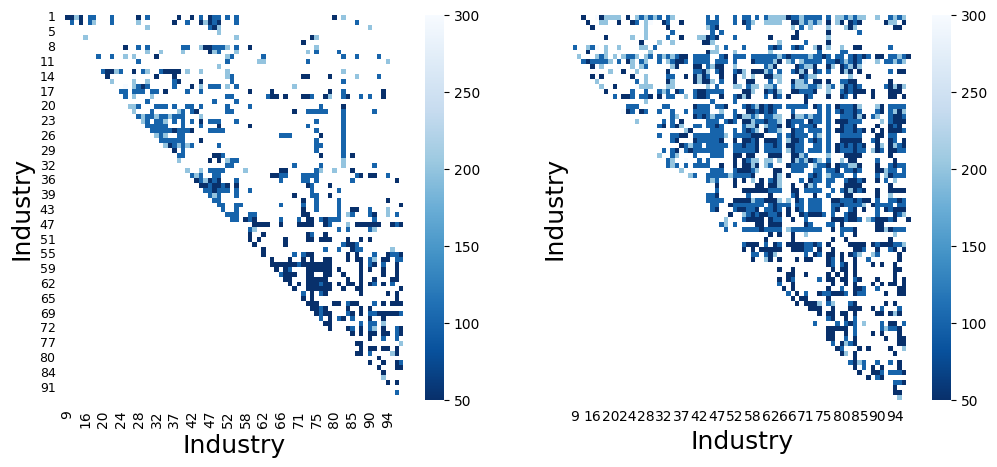

In [179]:
fig, ax = plt.subplots(1,2, figsize=(12,5), sharex=True, sharey=True)
fontsize=18

indind_matrix(idid_table, key_columns=["ind1", "ind2", "avg_dist_io_sr"], take_log=False, heatmap=True, size=fontsize, ax=ax[0])
indind_matrix(idid_table, key_columns=["ind1", "ind2", "avg_dist_io_not_sr"], take_log=False, heatmap=True, size=fontsize, ax=ax[1])

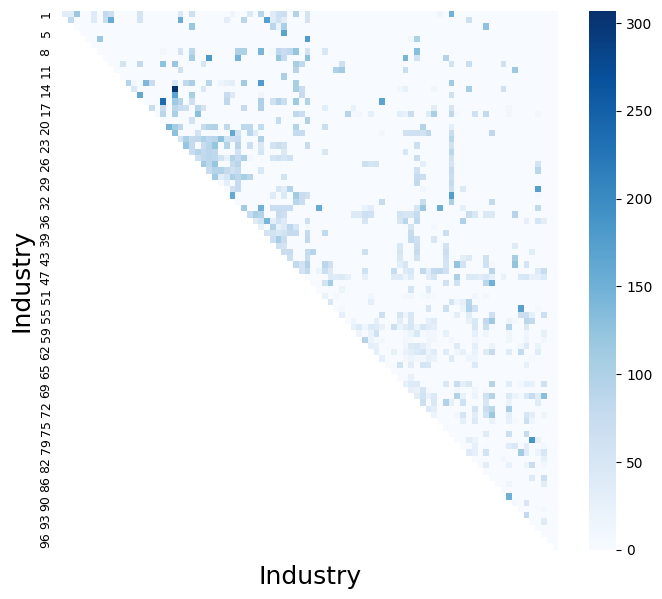

In [58]:

size=18
fig, ax = plt.subplots(1,1, figsize=(8,7))

pivot_table = idid_table.pivot_table(index="ind1", columns="ind2", values="avg_dist_io_sr", aggfunc="sum")
log_pivot_table = np.log10(pivot_table)

sns.heatmap(pivot_table, cbar=True, cmap="Blues", ax=ax)
#ax.set_title("Number of POIs", size=size)
ax.set_xlabel("Industry", size=size)
ax.set_ylabel("Industry", size=size)
ax.set_xticklabels("")
ax.tick_params("y", labelsize=9)
ax.tick_params(left = False, bottom = False)

<BarContainer object of 87 artists>

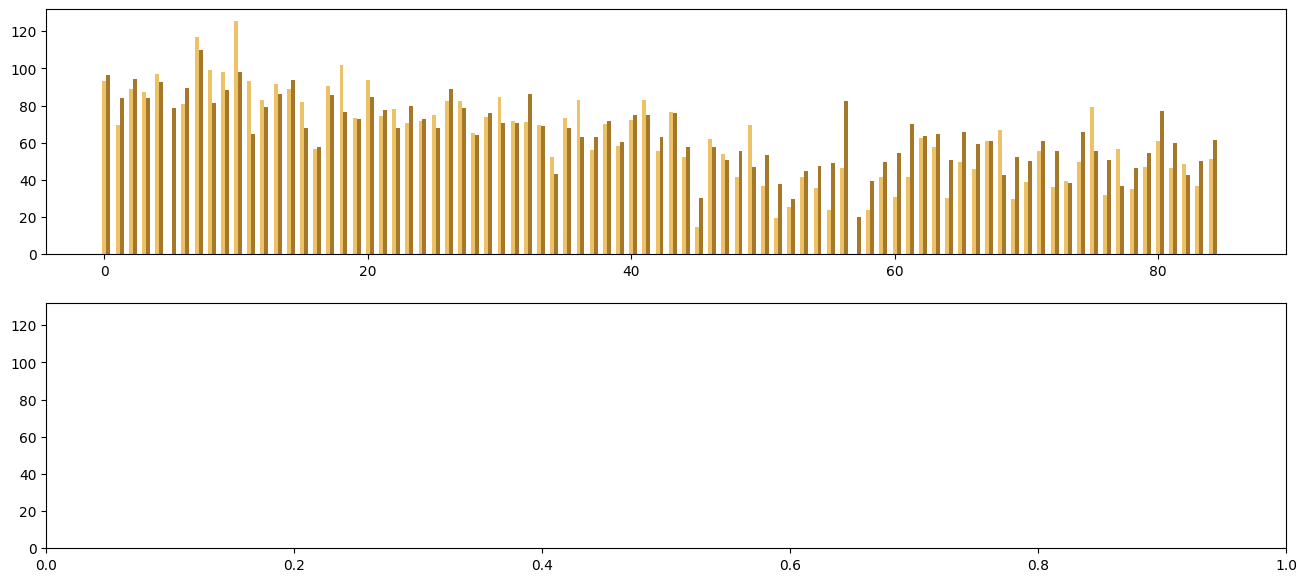

In [15]:
fig, ax = plt.subplots(2,1, figsize=(16,7), sharey=True)
fontsize=18


bar_width = 0.3
index = np.arange(len(test["ind1"]))

ax[0].bar(
        index,
        test["avg_dist_io_sr"],
        bar_width,
        label="Skill related firms",
        #yerr=[limited_df["share_io_sr_ties_ci"], limited_df["share_io_sr_ties_ci"]],
        #capsize=0,
        color="#EDC266"
)
ax[0].bar(
        index + bar_width,
        test["avg_dist_io_not_sr"],
        bar_width,
        label="Skill related firms",
        #yerr=[limited_df["share_io_sr_ties_ci"], limited_df["share_io_sr_ties_ci"]],
        #capsize=0,
        color="#A47828"
)


#ax[0].bar(test["ind1"], test["avg_dist_io_sr"], color="#3F8990")
#ax[1].bar(test["ind1"], test["avg_dist_io_not_sr"], color="#3F8990")

In [9]:
fig, ax = plt.subplots(1,1, figsize=(12,7))
fontsize=18


ax.bar(test["nace2d"], test["total_emp"], color="#3F8990")

ax[0].set_ylabel("Employment (log)", size=fontsize)
ax[0].tick_params("x", labelsize=(fontsize-2))
ax[0].tick_params("y", labelsize=(fontsize-2))
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].margins(0.015, tight=True)


# firms
ax[1].bar(ind_df["nace2d"], ind_df["total_firms"], color="#3F8990")
ax[1].semilogy()
ax[1].set_xlabel("Industries", size=fontsize)
ax[1].set_ylabel("Nr. firms (log)", size=fontsize)
ax[1].tick_params("x", labelsize=(fontsize-2))
ax[1].tick_params("y", labelsize=(fontsize-2))
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].margins(0.015, tight=True)

# subplot title
ax[0].annotate("A", xy=(-0.115,0.95), xycoords='axes fraction', xytext=(-8,12), textcoords='offset pixels', weight='bold', size=fontsize)
ax[0].annotate("B", xy=(-0.115,-0.25), xycoords='axes fraction', xytext=(-8,12), textcoords='offset pixels', weight='bold', size=fontsize)

# plt.savefig(f"../figures/si_industries_emp_firms.png", dpi=300, bbox_inches='tight', facecolor="white")

,ind1,nr_firms,avg_dist_io_all,sd_dist_io_all,nr_ties_io_all,avg_dist_lab_all,sd_dist_lab_all,nr_ties_lab_all,avg_dist_io_diffind,sd_dist_io_diffind,nr_ties_io_diffind,avg_dist_lab_diffind,sd_dist_lab_diffind,nr_ties_lab_diffind,avg_dist_io_sr,sd_dist_io_sr,nr_ties_io_sr,avg_dist_io_not_sr,sd_dist_io_not_sr,nr_ties_io_not_sr
0,1,17736,80.212,79.022,20347.0,62.113,71.902,29395.0,94.073,80.617,13991.0,94.073,80.617,13991.0,93.312,81.625,10597.0,96.450,77.349,3394.0
1,2,2328,68.943,69.239,2171.0,60.560,64.491,4067.0,75.422,74.165,1545.0,75.422,74.165,1545.0,69.432,75.186,907.0,83.937,71.892,638.0
2,3,212,97.825,70.672,354.0,72.192,70.177,832.0,91.875,70.680,208.0,91.875,70.680,208.0,88.670,74.065,88.0,94.225,68.311,120.0
3,5,22,79.469,63.703,32.0,56.808,62.006,26.0,84.767,62.236,30.0,84.767,62.236,30.0,87.429,47.088,7.0,83.957,67.068,23.0
4,6,7,91.328,79.340,61.0,42.409,47.539,22.0,94.424,78.832,59.0,94.424,78.832,59.0,97.125,74.101,24.0,92.571,82.934,35.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,94,3397,43.877,65.296,739.0,46.263,63.152,175.0,44.186,65.307,705.0,44.186,65.307,705.0,48.498,70.029,209.0,42.369,63.197,496.0
83,95,2819,43.901,62.371,790.0,45.123,65.864,1411.0,43.202,62.033,762.0,43.202,62.033,762.0,36.556,57.293,392.0,50.243,66.039,370.0
84,96,10284,57.219,67.314,688.0,50.107,64.746,8866.0,57.488,66.906,654.0,57.488,66.906,654.0,51.180,65.031,250.0,61.391,67.826,404.0
85,97,18,0.000,0.000,2.0,NaN,NaN,NaN,0.000,0.000,2.0,0.000,0.000,2.0,NaN,NaN,NaN,0.000,0.000,2.0


**Figure x - coagglomeration, IO connections, labor flow**

In [26]:
# load data
df3 = pd.read_csv(f"../data/oc10_2023_sep/oc_mdf3_{region_level}_{year}_based.csv", sep=";")

In [33]:
def z_score(values):
    new_values = (values - np.mean(values)) / (np.max(values) - np.min(values))
    return new_values

In [36]:
# variables manipulation
df3["coagg_stand"] = z_score(df3["egk_coagg"])
df3["io_stand"] = z_score(df3["io_norm"])
df3["lab_stand"] = z_score(df3["sr_norm"])

# clear setting
columns_to_consider = ["coagg_porter", "coagg_porter_mne", "coagg_porter_local", "io_stand", "lab_stand"]
df3 = df3.dropna(subset=columns_to_consider)

In [38]:
def matrix_represantation(df, key_columns, sort_matrix, heatmap, fontsize, title_text, cmap, ax=None):
    """matrix or pivot table representation of our key variables"""
    table = df[key_columns]

    # undirected to directed -- to have a full matrix
    table2 = table.copy().rename(columns={"ind1": "ind2", "ind2": "ind1"})
    table2 = table2[key_columns]
    table = pd.concat([table, table2])

    # pivot transformation
    table = pd.pivot_table(table,
        values=key_columns[2],
        index=key_columns[0],
        columns=key_columns[1],
        aggfunc=np.max,
        margins=True,
        margins_name='total')

    # option to sort the matrix
    if sort_matrix == True:
        table = table\
            .sort_values(by=["total"], ascending=False, axis=0)\
            .sort_values(by=["total"], ascending=False, axis=1)
    else:
        table = table
    
    table = table.drop(["total"], axis=1).drop(["total"], axis=0)
    
    # option to keep the table or create heatmap
    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(table, cbar=False, cmap=cmap, ax=ax)
        ax.set_xlabel("Industry", size=fontsize)
        ax.set_ylabel("Industry", size=fontsize)
        ax.set_title(title_text, size=fontsize)
        ax.yaxis.set_tick_params(rotation=0, labelbottom=True)
        #ax.set_xticklabels("")
        #ax.set_yticklabels("")
        ax.tick_params(left = False, bottom = False)

In [41]:
# matrix_represantation(df3, key_columns=["ind1", "ind2", "coagg_stand"], sort_matrix=False, heatmap=True, fontsize=25, title_text="EGK coagglomeration", cmap="Blues")

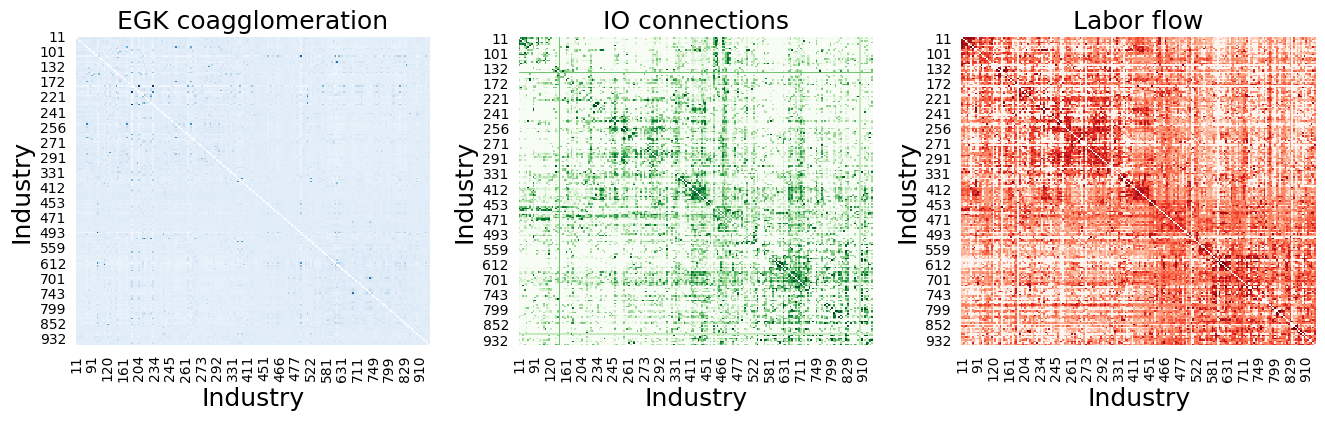

In [42]:
fig, ax = plt.subplots(1,3, figsize=(16,4), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.25)

matrix_represantation(
    df3,
    key_columns=["ind1", "ind2", "coagg_stand"],
    sort_matrix=False,
    heatmap=True,
    fontsize=18,
    title_text="EGK coagglomeration",
    cmap="Blues",
    ax=ax[0]
)

matrix_represantation(
    df3,
    key_columns=["ind1", "ind2", "io_stand"],
    sort_matrix=False,
    heatmap=True,
    fontsize=18,
    title_text="IO connections",
    cmap="Greens",
    ax=ax[1]
)

matrix_represantation(
    df3,
    key_columns=["ind1", "ind2", "lab_stand"],
    sort_matrix=False,
    heatmap=True,
    fontsize=18,
    title_text="Labor flow",
    cmap="Reds",
    ax=ax[2]
)

In [43]:
# add kde plots below the matrix row
def density_plot(df, key_column, colorway, xlabel_text, fontsize, ax=None):
    if ax is None:
        ax = plt.gca()
    if ax is None:
        ax = plt.gca()

    sns.kdeplot(data=df,
        x=key_column,
        fill=True,
        color=colorway,
        linewidth=2.5,
        log_scale=False,
        ax=ax)
    
    ax.set_xlabel(xlabel_text, size=fontsize)
    ax.set_ylabel("Density", size=fontsize)
    ax.tick_params("x", labelsize=(fontsize-5))
    ax.tick_params("y", labelsize=(fontsize-5))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

In [69]:
# density_plot(df3, key_column="coagg_stand", colorway = "#2C728EFF", xlabel_text="EGK coagglomeration", fontsize=15)

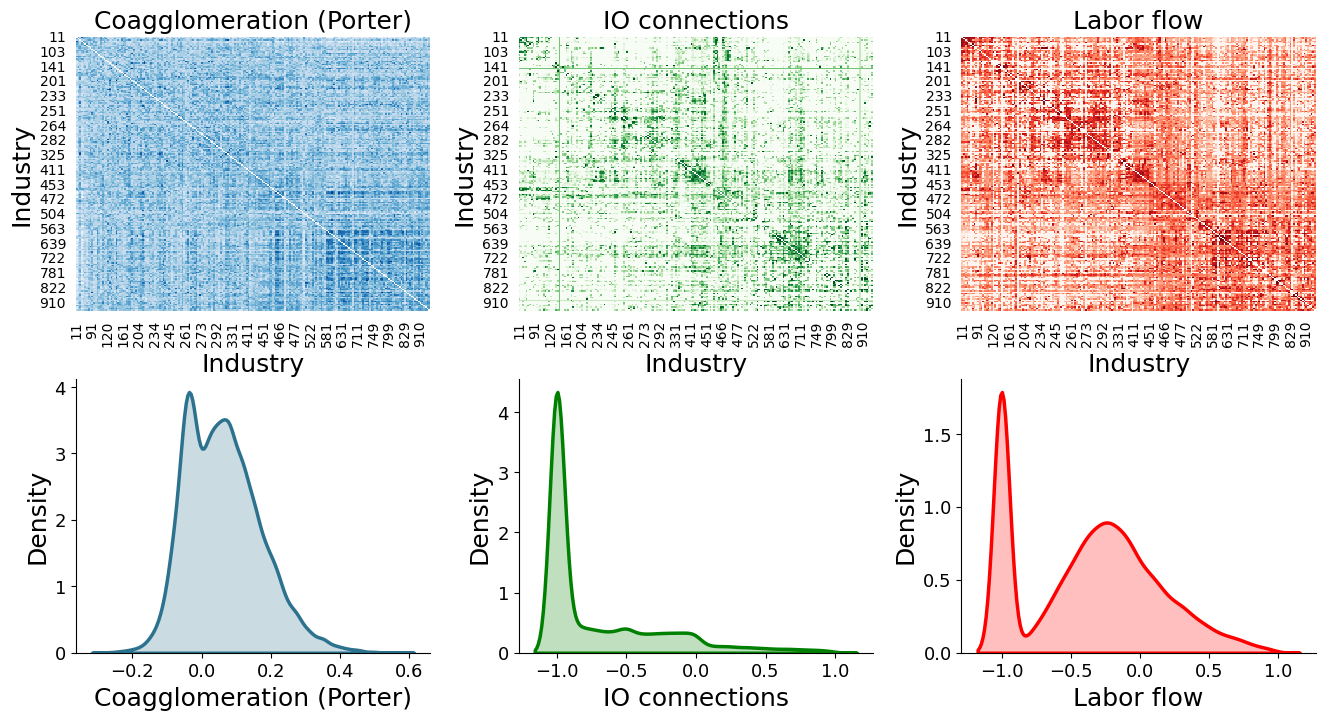

In [52]:
fig, ax = plt.subplots(2,3, figsize=(16,8))
plt.subplots_adjust(wspace=0.25, hspace=0.25)

matrix_represantation(
    df3,
    #key_columns=["ind1", "ind2", "egk_coagg"],
    key_columns=["ind1", "ind2", "coagg_porter"],
    sort_matrix=False,
    heatmap=True,
    fontsize=18,
    title_text="Coagglomeration (Porter)",
    cmap="Blues",
    ax=ax[0,0]
)

matrix_represantation(
    df3,
    key_columns=["ind1", "ind2", "io_norm"],
    sort_matrix=False,
    heatmap=True,
    fontsize=18,
    title_text="IO connections",
    cmap="Greens",
    ax=ax[0,1]
)

matrix_represantation(
    df3,
    key_columns=["ind1", "ind2", "sr_norm"],
    sort_matrix=False,
    heatmap=True,
    fontsize=18,
    title_text="Labor flow",
    cmap="Reds",
    ax=ax[0,2]
)

density_plot(
    df3,
    #key_column="egk_coagg",
    key_column="coagg_porter",
    colorway="#2C728EFF",
    xlabel_text="Coagglomeration (Porter)",
    fontsize=18,
    ax=ax[1,0]
)

density_plot(
    df3,
    key_column="io_norm",
    colorway="Green",
    xlabel_text="IO connections",
    fontsize=18,
    ax=ax[1,1]
)

density_plot(
    df3,
    key_column="sr_norm",
    colorway="Red",
    xlabel_text="Labor flow",
    fontsize=18,
    ax=ax[1,2]
)
